
# FFNN — PyTorch 2.x (simplificado)

Este cuaderno combina el **pipeline compacto** con `torch.compile`, early stopping y utilidades modernas,
**añadiendo** las funciones/clases que tenía tu versión original (datasets, EDA, loops `loop_FFNN/MC`,
`evaluate`, plots, etc.).


In [1]:

# [setup]
import os, math, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, Dataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
import optuna

torch.set_float32_matmul_precision('high')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
os.makedirs('checkpoints', exist_ok=True)
print('Device:', DEVICE)


/home/klefur/codigo/deep-learning/tarea1/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


In [2]:

# [model core]
def make_mlp(d_in: int, d_hidden=(64, 64), d_out=1, use_bn=False, dropout=0.0, act=nn.ReLU):
    layers = []
    d_prev = d_in
    for h in d_hidden:
        layers += [nn.Linear(d_prev, h)] # add linear layer
        if use_bn: layers += [nn.BatchNorm1d(h)] # add BN if specified
        layers += [act()] # add activation function
        if dropout > 0: layers += [nn.Dropout(dropout)] # add dropout if specified
        d_prev = h 
    layers += [nn.Linear(d_prev, d_out)]
    return nn.Sequential(*layers)

@torch.no_grad()
def accuracy_bin(logits, y_true):
    preds = (logits.sigmoid() >= 0.5).float().view(-1)
    return (preds == y_true.view(-1)).float().mean().item()

def set_seed(seed=42):
    import random
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


In [3]:

# [fit loop]
def fit(model, train_ds, val_ds=None, *, epochs=100, batch_size=64, lr=1e-3,
        patience=10, min_delta=1e-4, ckpt_path=None, compile_model=True, weight_decay=0.0):
    model.to(DEVICE)
    if compile_model and hasattr(torch, 'compile'):
        try:
            model = torch.compile(model)  # PyTorch 2.x
        except Exception as e:
            print('torch.compile no disponible:', e)

    sample_x, sample_y = train_ds[:][0], train_ds[:][1]
    binary = sample_y.ndim == 2 or sample_y.unique().numel() <= 2
    if binary:
        criterion = nn.BCEWithLogitsLoss()
    else:
        criterion = nn.CrossEntropyLoss()

    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    best = math.inf; best_epoch = None; best_state = None
    history = {'epoch': [], 'loss': [], 'acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(1, epochs+1):
        model.train()
        epoch_loss = 0.0; n = 0; accs = []
        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            logits = model(xb)
            if binary:
                yb_f = yb.float().view(-1,1)
                loss = criterion(logits, yb_f)
                acc = accuracy_bin(logits.detach(), yb.detach().float())
            opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
            epoch_loss += loss.item()*xb.size(0); n += xb.size(0); accs.append(acc)
        tr_loss = epoch_loss/n; tr_acc = float(np.mean(accs))

        # Validación
        if val_ds is not None:
            model.eval()
            xb, yb = val_ds[:]
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            with torch.no_grad():
                logits = model(xb)
                if binary:
                    val_loss = criterion(logits, yb.float().view(-1,1)).item()
                    val_acc = accuracy_bin(logits, yb.float())
            if val_loss + min_delta < best:
                best = val_loss; best_epoch = epoch; best_state = {k:v.cpu() for k,v in model.state_dict().items()}
                if ckpt_path: torch.save(best_state, ckpt_path)

        history['epoch'].append(epoch)
        history['loss'].append(tr_loss); history['acc'].append(tr_acc)
        if val_ds is not None:
            history['val_loss'].append(val_loss); history['val_acc'].append(val_acc)

        if epoch % 5 == 0:
            msg = f"[{epoch:03d}] loss={tr_loss:.4f} acc={tr_acc*100:5.1f}%"
            if val_ds is not None:
                msg += f" | vloss={val_loss:.4f} vacc={val_acc*100:5.1f}%"
            print(msg)

        # early stopping
        if val_ds is not None and (epoch - (best_epoch or 0)) >= patience:
            print(f"Paro temprano @ epoch {epoch} (best={best_epoch})")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history, best_epoch


In [4]:
class OccupancyDataset(Dataset):
    def __init__(self, X_np, y_np):

        self.X = torch.tensor(X_np.astype(np.float32))
        self.y = torch.tensor(y_np.astype(np.int64))

        self.num_features = self.X.shape[1]
        self.n_classes = len(torch.unique(self.y))
    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [5]:

# [compat: EDA helpers]
def eda_hist_grid(X, bins=20, title_prefix=""):
    Xn = np.asarray(X); d = Xn.shape[1]
    cols = min(6, d); rows = int(np.ceil(d/cols))
    plt.figure(figsize=(2.8*cols, 2.2*rows))
    for i in range(d):
        ax = plt.subplot(rows, cols, i+1)
        ax.hist(Xn[:,i], bins=bins)
        ax.set_title(f'Var {i}')
    plt.suptitle(f'{title_prefix} - Histogramas'); plt.tight_layout(); plt.show()

def eda_corr_heatmap(X, title_prefix=""):
    Xn = np.asarray(X)
    corr = np.corrcoef(Xn, rowvar=False)
    plt.figure(figsize=(5,4))
    im = plt.imshow(corr, aspect='auto'); plt.colorbar(im)
    plt.title(f"{title_prefix} - Correlación (Pearson)"); plt.xlabel('Feature'); plt.ylabel('Feature'); plt.show()

def eda_feature_bars(X, title_prefix=""):
    Xn = np.asarray(X)
    means = Xn.mean(axis=0); stds = Xn.std(axis=0)
    idx = np.arange(Xn.shape[1])
    plt.figure(figsize=(8,3)); plt.bar(idx, means); plt.title(f"{title_prefix} - Media por variable")
    plt.xlabel('Feature'); plt.ylabel('Media'); plt.show()
    plt.figure(figsize=(8,3)); plt.bar(idx, stds); plt.title(f"{title_prefix} - Desvío estándar por variable")
    plt.xlabel('Feature'); plt.ylabel('STD'); plt.show()

def plot_randomdataset_class_balance(y, title_prefix="Random"):
    y = np.asarray(y).astype(int)
    vals, counts = np.unique(y, return_counts=True)
    plt.figure(figsize=(4,3)); plt.bar(vals, counts); plt.title(f"{title_prefix} - Balance de clases"); plt.xlabel('Clase'); plt.ylabel('Count'); plt.show()

def plot_randomdataset_feature_density(X, idx=0, title_prefix="Random"):
    Xn = np.asarray(X)
    plt.figure(figsize=(4,3)); plt.hist(Xn[:, idx], bins=30); plt.title(f"{title_prefix} - Densidad feature {idx}"); plt.show()

def plot_randomdataset_heatmap(X, title_prefix="Random"):
    eda_corr_heatmap(X, title_prefix=title_prefix)

def plot_randomdataset_sample_ones_hist(X, y, title_prefix="Random"):
    Xn = np.asarray(X); y = np.asarray(y).astype(int)
    X1 = Xn[y==1]
    if X1.size==0:
        print("No hay clase 1 en la muestra"); return
    eda_hist_grid(X1, title_prefix=f"{title_prefix} (clase 1)")


Preparing Occupancy dataset...


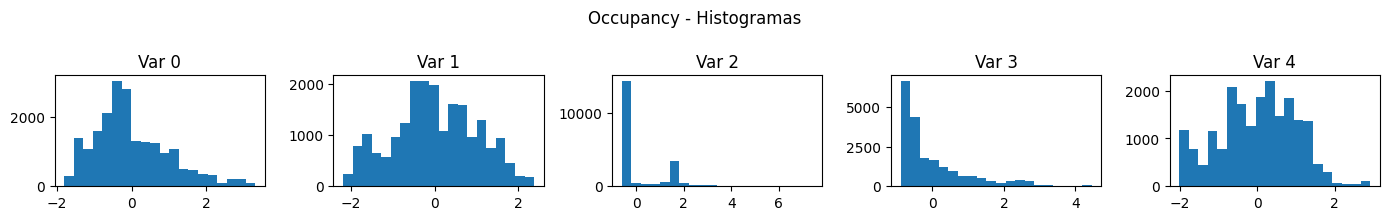

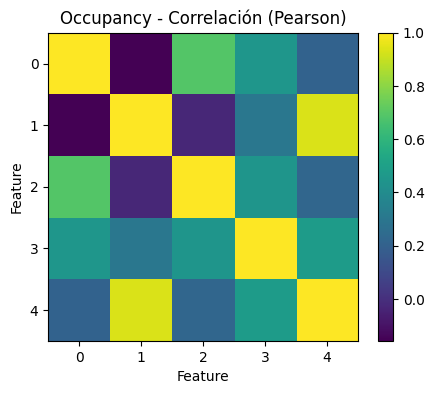

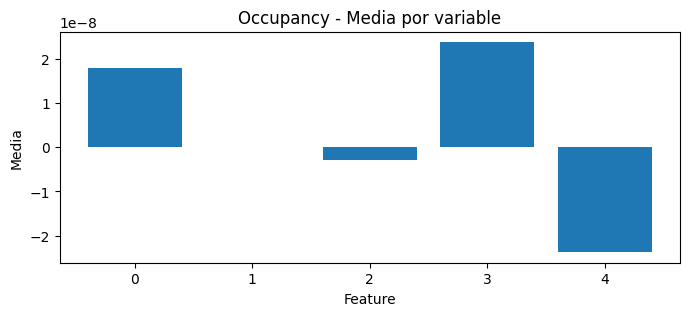

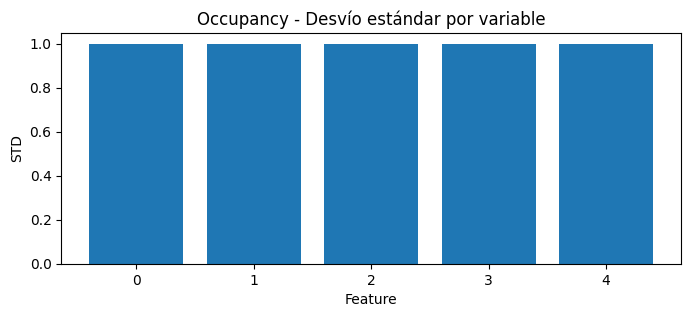

In [6]:
# [EDA de datasets]

# Occupancy (binary)
print("Preparing Occupancy dataset...")
# Dataset
occupancy_detection = fetch_ucirepo(id=357)

# Data
X = occupancy_detection.data.features
y = occupancy_detection.data.targets

# Drop date column as it is not useful for multivariate analysis
X = X.drop(columns=["date"])

# Clean headers put in dataset
X = X.apply(pd.to_numeric, errors='coerce')
X = X.dropna()
y = y.apply(pd.to_numeric, errors='coerce')
y = y.dropna()

X_np = X.to_numpy()
y_np = y.to_numpy()

X_np_scaled = StandardScaler().fit_transform(X_np)

# Occupancy
oc = OccupancyDataset(X_np_scaled, y_np)
eda_hist_grid(oc.X, title_prefix="Occupancy")
eda_corr_heatmap(oc.X, title_prefix="Occupancy")
eda_feature_bars(oc.X, title_prefix="Occupancy")

In [7]:

# [compat: models with names FFNN]
class FFNN(nn.Module):

    def __init__(self, d0, d1=64, d2=64, dropout=0.0, use_bn=False, method='he'):
        super().__init__()
        self.method = method
        self.net = make_mlp(d0, (d1, d2), 1, use_bn=use_bn,dropout=dropout)
        self.net.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            if self.method == 'he':
                nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')
            elif self.method == 'xavier':
                nn.init.xavier_normal_(m.weight)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        
    def forward(self, x): return self.net(x)

In [8]:

# [compat: evaluation & plotting]
@torch.no_grad()
def evaluate(model, dataset, binary=True, batch_size=256):
    model.eval(); loader = DataLoader(dataset, batch_size=batch_size)
    total=0; correct=0; losses=[]; crit = nn.BCEWithLogitsLoss() if binary else nn.CrossEntropyLoss()
    all_y=[]; all_p=[]
    for xb, yb in loader:
        xb = xb.to(DEVICE); yb = yb.to(DEVICE)
        logits = model(xb)
        if binary:
            loss = crit(logits, yb.float().view(-1,1))
            preds = (logits.sigmoid()>=0.5).float().view(-1)
            all_p.append(preds.cpu().numpy()); all_y.append(yb.view(-1).cpu().numpy())
        else:
            loss = crit(logits, yb.long())
            preds = logits.argmax(1)
            all_p.append(preds.cpu().numpy()); all_y.append(yb.view(-1).cpu().numpy())
        total += yb.size(0); correct += (preds == yb.view(-1)).float().sum().item(); losses.append(loss.item())
    acc = correct/total
    y_true = np.concatenate(all_y); y_pred = np.concatenate(all_p)
    cm = confusion_matrix(y_true, y_pred)
    rep = classification_report(y_true, y_pred, output_dict=False)
    return {'acc': acc, 'loss': float(np.mean(losses)), 'cm': cm, 'report': rep}

@torch.no_grad()
def evaluate_per_class(model, dataset, binary=False, batch_size=256):
    # simple wrapper que devuelve matriz de confusión y métricas por clase del classification_report
    e = evaluate(model, dataset, binary=binary, batch_size=batch_size)
    return e

def plot_history_loss(h):
    x = h['epoch'];
    plt.figure(); plt.plot(x, h['loss'], label='train_loss')
    if h.get('val_loss'): plt.plot(x, h['val_loss'], label='val_loss')
    plt.xlabel('Época'); plt.ylabel('Loss'); plt.title('Histórico Loss'); plt.legend(); plt.show()

def plot_history_acc(h):
    x = h['epoch'];
    plt.figure(); plt.plot(x, np.array(h['acc'])*100, label='train_acc')
    if h.get('val_acc'): plt.plot(x, np.array(h['val_acc'])*100, label='val_acc')
    plt.xlabel('Época'); plt.ylabel('Acc (%)'); plt.title('Histórico Acc'); plt.legend(); plt.show()

def plot_with_best_epoch(h, best_epoch):
    plot_history_loss(h); plot_history_acc(h)
    if best_epoch:
        print(f"Mejor época (val_loss): {best_epoch}")


In [9]:

# [plots with best epoch]
def plot_history(h, best_epoch=None, title='Histórico'):
    x = h['epoch']
    # Loss
    plt.figure()
    plt.plot(x, h['loss'], label='train_loss')
    if h.get('val_loss') and len(h['val_loss']) == len(x):
        plt.plot(x, h['val_loss'], label='val_loss')
    if best_epoch:
        plt.axvline(best_epoch, linestyle='--')
        plt.text(best_epoch, plt.ylim()[1]*0.9, f"best={best_epoch}", rotation=90, va='top')
    plt.xlabel('Época'); plt.ylabel('Loss'); plt.title(title + ' - Loss'); plt.legend(); plt.show()
    # Acc
    plt.figure()
    plt.plot(x, [a*100 for a in h['acc']], label='train_acc')
    if h.get('val_acc') and len(h['val_acc']) == len(x):
        plt.plot(x, [a*100 for a in h['val_acc']], label='val_acc')
    if best_epoch:
        plt.axvline(best_epoch, linestyle='--')
        plt.text(best_epoch, plt.ylim()[1]*0.9, f"best={best_epoch}", rotation=90, va='top')
    plt.xlabel('Época'); plt.ylabel('Acc (%)'); plt.title(title + ' - Acc'); plt.legend(); plt.show()

def plot_with_best_epoch(h, best_epoch):
    plot_history(h, best_epoch=best_epoch, title='Entrenamiento')


In [10]:

# [compat: loops]
def loop_FFNN(dataset, batch_size, d1, d2, lr, epochs,
              run_in_GPU=True, log_history=False, val_dataset=None, early_stopping=False,
              patience=10, min_delta=1e-4, checkpoint_path=None, weight_decay=0.0,
              method='he', dropout=0.0, use_bn=False):
    d0 = dataset.num_features
    model = FFNN(d0, d1, d2, use_bn=use_bn, dropout=dropout, method=method).to(DEVICE if run_in_GPU else 'cpu')
    # Adapter: wrap dataset into TensorDataset for our fit()
    tr = TensorDataset(dataset.X, dataset.y)
    val = TensorDataset(val_dataset.X, val_dataset.y)
    model, hist, best = fit(model, tr, val_ds=val,
                            epochs=epochs, lr=lr, batch_size=batch_size, patience=patience,
                            min_delta=min_delta, ckpt_path=checkpoint_path, weight_decay=weight_decay)
    if log_history:
        plot_with_best_epoch(hist, best)
    return model, hist, best

In [15]:

# [Data preparation]
set_seed(42)
N_TRIALS = 50

print("Splitting Occupancy dataset...")
X_train, X_test, y_train, y_test = train_test_split(
    X_np_scaled, y_np, test_size=0.2, stratify=y_np, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)   

oc_train = OccupancyDataset(X_train, y_train)
oc_val = OccupancyDataset(X_val, y_val)
oc_test = OccupancyDataset(X_test, y_test)

Splitting Occupancy dataset...


In [16]:
def objective(trial):
    """
    Optuna objective function to find the best hyperparameters.
    """
    
    # --- 1. Define the hyperparameter search space ---
    
    # Hidden layers d1 and d2 (integers, log scale)
    d1 = trial.suggest_int('d1', 32, 256, log=True)
    d2 = trial.suggest_int('d2', 32, 256, log=True)
    
    # Learning rate (float, log scale)
    lr = trial.suggest_float('lr', 1e-5, 1e-1, log=True)
    
    # Weight decay (for AdamW)
    weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-2, log=True)
    
    # Dropout rate (float, linear scale)
    dropout = trial.suggest_float('dropout', 0.0, 0.5, step=0.1)
    
    # Batch size (categorical, powers of 2)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])
    
    # Initialization method
    method = trial.suggest_categorical('method', ['he', 'xavier'])

    use_bn = trial.suggest_categorical('use_bn', [True, False])

    # --- 2. Run the training loop ---
    
    # Define a fixed number of epochs for optimization.
    # Early stopping ('patience') will handle bad trials.
    EPOCHS_FOR_OPTUNA = 50 
    
    model, hist, best = loop_FFNN(
        dataset=oc_train,        # Use your training dataset
        val_dataset=oc_val,      # Use your validation dataset
        batch_size=batch_size,
        d1=d1,
        d2=d2,
        lr=lr,
        epochs=EPOCHS_FOR_OPTUNA,
        dropout=dropout,
        weight_decay=weight_decay,
        use_bn=use_bn,               # Enable batch normalization
        method=method,
        run_in_GPU=True,
        log_history=False,            # Disable logging during optimization
        patience=10                   # Early stopping patience
    )

    # --- 3. Return the metric to optimize ---
    
    # !! IMPORTANT: Assuming 'hist' is a dict and 'best' is the index of the best epoch.
    # Assuming 'hist' contains 'val_acc' (validation accuracy).
    # If measuring 'val_loss', change 'direction' to 'minimize'.
    
    try:
        # Return the validation accuracy at the best epoch
        best_val_accuracy = hist['val_acc'][best]
        return best_val_accuracy
    except (KeyError, TypeError, IndexError):
        # Fallback if history is empty, 'best' is not an index, or key is missing
        print("Warning: Could not extract metric from history. Returning 0.0.")
        return 0.0

In [ ]:

print("Starting hyperparameter optimization with Optuna...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=N_TRIALS)
print("Best trial:")
trial = study.best_trial
print(f"  Value: {trial.value}")
print("  Params: ")
for key, value in trial.params.items():
    print(f"    {key}: {value}")

[I 2025-11-15 19:28:25,034] A new study created in memory with name: no-name-18d37dff-51d8-4d08-a87f-ec54446a354c


Starting hyperparameter optimization with Optuna...


W1115 19:28:30.324000 13731 torch/_inductor/utils.py:1613] [0/0] Not enough SMs to use max_autotune_gemm mode


[005] loss=0.1033 acc= 97.0% | vloss=0.0661 vacc= 98.8%
[010] loss=0.0789 acc= 97.7% | vloss=0.0541 vacc= 98.8%
[015] loss=0.0676 acc= 98.1% | vloss=0.0459 vacc= 98.9%
[020] loss=0.0616 acc= 98.3% | vloss=0.0439 vacc= 98.9%
[025] loss=0.0588 acc= 98.4% | vloss=0.0445 vacc= 98.7%
[030] loss=0.0559 acc= 98.4% | vloss=0.0429 vacc= 98.9%
[035] loss=0.0544 acc= 98.5% | vloss=0.0411 vacc= 99.0%
[040] loss=0.0536 acc= 98.5% | vloss=0.0437 vacc= 98.7%
[045] loss=0.0505 acc= 98.6% | vloss=0.0403 vacc= 99.0%


[I 2025-11-15 19:28:57,110] Trial 0 finished with value: 0.0 and parameters: {'d1': 36, 'd2': 129, 'lr': 0.00027983147648690833, 'weight_decay': 3.271710065532815e-05, 'dropout': 0.4, 'batch_size': 64, 'method': 'he', 'use_bn': True}. Best is trial 0 with value: 0.0.


...

[050] loss=0.0295 acc= 99.1% | vloss=0.0287 vacc= 99.1%
[005] loss=0.0419 acc= 98.9% | vloss=0.0405 vacc= 99.0%
[010] loss=0.0387 acc= 98.9% | vloss=0.0325 vacc= 99.0%
[015] loss=0.0359 acc= 98.9% | vloss=0.0346 vacc= 99.1%
[020] loss=0.0351 acc= 98.9% | vloss=0.0288 vacc= 99.1%
[025] loss=0.0341 acc= 98.9% | vloss=0.0293 vacc= 99.2%
[030] loss=0.0320 acc= 99.0% | vloss=0.0302 vacc= 99.3%


[I 2025-11-15 19:44:32,879] Trial 48 finished with value: 0.9911853671073914 and parameters: {'d1': 113, 'd2': 83, 'lr': 0.006763832268657265, 'weight_decay': 1.6589417148010268e-06, 'dropout': 0.1, 'batch_size': 64, 'method': 'he', 'use_bn': False}. Best is trial 21 with value: 0.9920971989631653.


Paro temprano @ epoch 32 (best=22)
[005] loss=0.0493 acc= 98.8% | vloss=0.0451 vacc= 99.0%
[010] loss=0.0452 acc= 98.8% | vloss=0.0415 vacc= 99.0%
[015] loss=0.0433 acc= 98.8% | vloss=0.0395 vacc= 99.0%
[020] loss=0.0419 acc= 98.8% | vloss=0.0379 vacc= 99.0%
[025] loss=0.0411 acc= 98.8% | vloss=0.0369 vacc= 99.0%
[030] loss=0.0402 acc= 98.8% | vloss=0.0362 vacc= 99.0%
[035] loss=0.0394 acc= 98.8% | vloss=0.0352 vacc= 99.0%
[040] loss=0.0387 acc= 98.8% | vloss=0.0343 vacc= 99.0%
[045] loss=0.0381 acc= 98.8% | vloss=0.0339 vacc= 99.0%


[I 2025-11-15 19:44:50,675] Trial 49 finished with value: 0.9902735352516174 and parameters: {'d1': 32, 'd2': 97, 'lr': 0.0002920700894258779, 'weight_decay': 0.0031644638277797893, 'dropout': 0.0, 'batch_size': 64, 'method': 'xavier', 'use_bn': False}. Best is trial 21 with value: 0.9920971989631653.


[050] loss=0.0372 acc= 98.9% | vloss=0.0335 vacc= 99.0%
Best trial:
  Value: 0.9920971989631653
  Params: 
    d1: 74
    d2: 102
    lr: 0.0032135823223819757
    weight_decay: 5.0662346540021936e-05
    dropout: 0.2
    batch_size: 32
    method: he
    use_bn: False


Best trial:
  Value: 0.9924011826515198
  Params: 
    d1: 137
    d2: 41
    lr: 0.0020397385279134037
    weight_decay: 0.0020879906178267473
    dropout: 0.2
    batch_size: 128
    method: he
    use_bn: False

W1115 19:51:49.331000 17204 torch/_inductor/utils.py:1613] [0/0] Not enough SMs to use max_autotune_gemm mode


[005] loss=0.0459 acc= 98.8% | vloss=0.0382 vacc= 99.0%
[010] loss=0.0425 acc= 98.8% | vloss=0.0354 vacc= 99.0%
[015] loss=0.0400 acc= 98.8% | vloss=0.0350 vacc= 99.0%
[020] loss=0.0386 acc= 98.8% | vloss=0.0319 vacc= 99.1%
[025] loss=0.0374 acc= 98.9% | vloss=0.0312 vacc= 99.0%
[030] loss=0.0366 acc= 98.9% | vloss=0.0340 vacc= 99.0%
[035] loss=0.0361 acc= 98.9% | vloss=0.0317 vacc= 99.1%
[040] loss=0.0363 acc= 98.9% | vloss=0.0314 vacc= 99.0%
[045] loss=0.0340 acc= 98.9% | vloss=0.0305 vacc= 99.1%
[050] loss=0.0349 acc= 98.9% | vloss=0.0320 vacc= 99.0%
[055] loss=0.0344 acc= 99.0% | vloss=0.0312 vacc= 99.1%
Paro temprano @ epoch 57 (best=47)


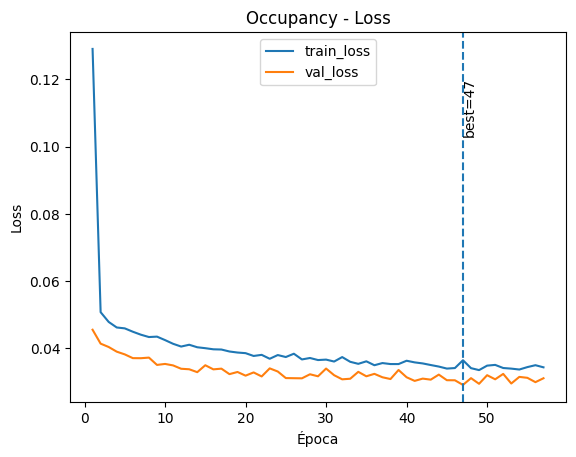

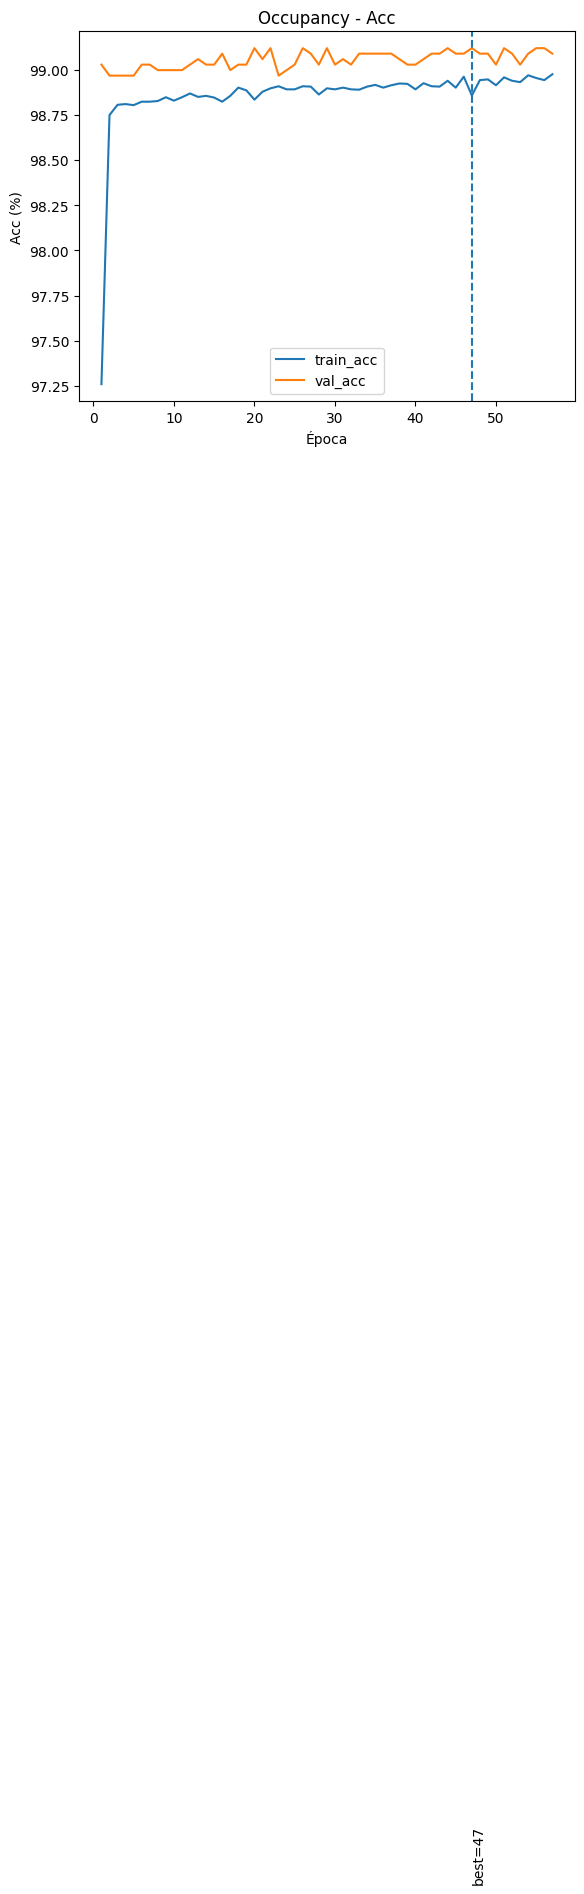

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      3162
           1       0.96      1.00      0.98       950

    accuracy                           0.99      4112
   macro avg       0.98      0.99      0.99      4112
weighted avg       0.99      0.99      0.99      4112

[[3125   37]
 [   4  946]]


In [17]:
model_oc, hist_oc, best_oc = loop_FFNN(oc_train, val_dataset=oc_val,batch_size=128, d1=137, d2=41, 
                                       lr=2.03e-3, weight_decay=2.08e-3, epochs=200,
                                       use_bn=False,log_history=False, method='xavier', 
                                       dropout=0.2)
plot_history(hist_oc, best_epoch=best_oc, title='Occupancy')
ev_oc = evaluate(model_oc, TensorDataset(oc_test.X, oc_test.y), binary=True)
print(ev_oc['report'])
print(ev_oc['cm'])

In [18]:
# [Bootstrap]

def bootstrap_evaluate(train_dataset, eval_datasetet, n_bootstraps=10):
    results = []
    n_samples = len(train_dataset)
    for i in range(n_bootstraps):
        # Crear muestra bootstrap
        indices = np.random.choice(n_samples, size=n_samples, replace=True)
        X_bootstrap = train_dataset.X[indices]
        y_bootstrap = train_dataset.y[indices]
        bootstrap_dataset = OccupancyDataset(X_bootstrap.numpy(), y_bootstrap.numpy())
        
        # Entrenar modelo en la muestra bootstrap
        model, hist, best = loop_FFNN(
            dataset=bootstrap_dataset,
            val_dataset=eval_datasetet,
            batch_size=128,
            d1=201,
            d2=62,
            lr=2.03e-3,
            epochs=200,
            weight_decay=2.08e-3,
            use_bn=False,
            dropout=0.2,
            method='xavier',
            run_in_GPU=True,
            log_history=False,
            patience=10
        )
        
        # Evaluar el modelo entrenado en el conjunto de evaluación
        eval_result = evaluate(model, TensorDataset(eval_datasetet.X, eval_datasetet.y), binary=True)
        results.append(eval_result)
        print(f"Bootstrap {i+1}/{n_bootstraps} - Acc: {eval_result['acc']*100:.2f}%")
    
    return results

In [19]:
results = bootstrap_evaluate(oc_train, oc_val, n_bootstraps=10)

[005] loss=0.0470 acc= 98.8% | vloss=0.0389 vacc= 98.9%
[010] loss=0.0414 acc= 98.9% | vloss=0.0342 vacc= 99.0%
[015] loss=0.0396 acc= 98.9% | vloss=0.0326 vacc= 99.0%
[020] loss=0.0385 acc= 98.8% | vloss=0.0341 vacc= 99.0%
[025] loss=0.0370 acc= 98.9% | vloss=0.0310 vacc= 99.1%
[030] loss=0.0370 acc= 98.9% | vloss=0.0316 vacc= 99.1%
[035] loss=0.0358 acc= 98.9% | vloss=0.0308 vacc= 99.1%
[040] loss=0.0347 acc= 98.9% | vloss=0.0314 vacc= 99.1%
[045] loss=0.0336 acc= 99.0% | vloss=0.0326 vacc= 99.1%
[050] loss=0.0331 acc= 99.0% | vloss=0.0316 vacc= 99.1%
[055] loss=0.0321 acc= 99.0% | vloss=0.0303 vacc= 99.1%
[060] loss=0.0330 acc= 99.0% | vloss=0.0293 vacc= 99.1%
[065] loss=0.0317 acc= 99.0% | vloss=0.0305 vacc= 99.1%
Paro temprano @ epoch 66 (best=56)
Bootstrap 1/10 - Acc: 99.15%
[005] loss=0.0461 acc= 98.7% | vloss=0.0372 vacc= 99.0%
[010] loss=0.0408 acc= 98.8% | vloss=0.0359 vacc= 99.0%
[015] loss=0.0380 acc= 98.8% | vloss=0.0334 vacc= 99.0%
[020] loss=0.0369 acc= 98.9% | vloss=0.0

In [20]:
def ensemble(train_dataset, eval_dataset):
    models = []

    params = [
        {
            'weight_decay': 0,
            'dropout': 0.2,
        },
        {
            'weight_decay': 2.08e-3,
            'dropout': 0.0,
        },
        {
            'weight_decay': 0.0,
            'dropout': 0.0,
        }
    ]

    for i in range(3):
        # Entrenar modelo
        model, hist, best = loop_FFNN(
            dataset=train_dataset,
            val_dataset=eval_dataset,
            batch_size=128,
            d1=201,
            d2=62,
            lr=2.03e-3,
            epochs=200,
            weight_decay=params[i]['weight_decay'],
            dropout=params[i]['dropout'],
            method='xavier',
            use_bn=True,
            run_in_GPU=True,
            log_history=False,
            patience=10
        )
        models.append(model)
        print(f"Modelo {i+1}/{3} entrenado.")

    
    
    return models


def evaluate_ensemble(models, test_dataset):
    total=0; correct=0; losses=[]; crit = nn.BCEWithLogitsLoss()
    all_y=[]; all_p=[]
    for xb, yb in DataLoader(test_dataset, batch_size=128):
        xb = xb.to(DEVICE); yb = yb.to(DEVICE)
        # Promediar las predicciones de todos los modelos
        logits_sum = torch.zeros((xb.size(0), 1), device=DEVICE)
        for model in models:
            model.eval()
            with torch.no_grad():
                logits = model(xb)
                logits_sum += logits
        logits_avg = logits_sum / len(models)
        
        loss = crit(logits_avg, yb.float().view(-1,1))
        preds = (logits_avg.sigmoid()>=0.5).float().view(-1)
        all_p.append(preds.cpu().numpy()); all_y.append(yb.view(-1).cpu().numpy())
        total += yb.size(0); correct += (preds == yb.view(-1)).float().sum().item(); losses.append(loss.item())
    acc = correct/total
    y_true = np.concatenate(all_y); y_pred = np.concatenate(all_p)
    cm = confusion_matrix(y_true, y_pred)
    rep = classification_report(y_true, y_pred, output_dict=False)
    return {'acc': acc, 'loss': float(np.mean(losses)), 'cm': cm, 'report': rep}

In [21]:
ensemble_models = ensemble(oc_train, oc_val)
ensemble_eval = evaluate_ensemble(ensemble_models, oc_test)
print("Ensemble Evaluation Report:")
print(ensemble_eval['report'])

[005] loss=0.0459 acc= 98.8% | vloss=0.0371 vacc= 99.0%
[010] loss=0.0419 acc= 98.8% | vloss=0.0356 vacc= 99.0%
[015] loss=0.0405 acc= 98.8% | vloss=0.0338 vacc= 99.0%
[020] loss=0.0402 acc= 98.7% | vloss=0.0328 vacc= 99.0%
[025] loss=0.0372 acc= 98.9% | vloss=0.0330 vacc= 98.9%
[030] loss=0.0371 acc= 98.9% | vloss=0.0306 vacc= 99.1%
[035] loss=0.0365 acc= 98.9% | vloss=0.0323 vacc= 99.0%
[040] loss=0.0358 acc= 98.9% | vloss=0.0324 vacc= 99.1%
Paro temprano @ epoch 41 (best=31)
Modelo 1/3 entrenado.


W1115 19:54:10.214000 17204 torch/_dynamo/convert_frame.py:1358] [0/8] torch._dynamo hit config.recompile_limit (8)
W1115 19:54:10.214000 17204 torch/_dynamo/convert_frame.py:1358] [0/8]    function: 'forward' (/tmp/ipykernel_17204/4200915070.py:19)
W1115 19:54:10.214000 17204 torch/_dynamo/convert_frame.py:1358] [0/8]    last reason: 0/7: GLOBAL_STATE changed: grad_mode 
W1115 19:54:10.214000 17204 torch/_dynamo/convert_frame.py:1358] [0/8] To log all recompilation reasons, use TORCH_LOGS="recompiles".
W1115 19:54:10.214000 17204 torch/_dynamo/convert_frame.py:1358] [0/8] To diagnose recompilation issues, see https://pytorch.org/docs/main/torch.compiler_troubleshooting.html


[005] loss=0.0418 acc= 98.8% | vloss=0.0372 vacc= 98.9%
[010] loss=0.0399 acc= 98.8% | vloss=0.0338 vacc= 99.1%
[015] loss=0.0367 acc= 98.9% | vloss=0.0314 vacc= 99.1%
[020] loss=0.0367 acc= 98.9% | vloss=0.0314 vacc= 99.0%
[025] loss=0.0349 acc= 98.9% | vloss=0.0319 vacc= 99.1%
Paro temprano @ epoch 26 (best=16)
Modelo 2/3 entrenado.
[005] loss=0.0411 acc= 98.8% | vloss=0.0354 vacc= 99.0%
[010] loss=0.0385 acc= 98.8% | vloss=0.0334 vacc= 99.0%
[015] loss=0.0383 acc= 98.9% | vloss=0.0324 vacc= 99.1%
Paro temprano @ epoch 19 (best=9)
Modelo 3/3 entrenado.
Ensemble Evaluation Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      3162
           1       0.96      1.00      0.98       950

    accuracy                           0.99      4112
   macro avg       0.98      0.99      0.99      4112
weighted avg       0.99      0.99      0.99      4112

